# Meteorological Risk Factors for Plasmopara viticola Infection in European Vineyards
## A Data Science Analysis of Disease Occurrence and Meteorological Conditions

**SoftUni Data Science Program — Final Exam Project**  
**Author:** Pavel Ivanov  


## 1. Setup - Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import folium
import requests
import time
import scipy
import sklearn


plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

warnings.filterwarnings("ignore")

# Bordeaux dataset
bordeaux = pd.read_excel('../data/raw/plosone_bordeaux_downy_mildew_s1.xlsx')

print(f"Shape: {bordeaux.shape}")
print(f"\nColumns:\n{list(bordeaux.columns)}")
bordeaux.head()

Shape: (156, 15)

Columns:
['Id_Parc', 'Date_App', 'Year', 'Mar_p_total_moy', 'Apr_p_total_moy', 'May_p_total_moy', 'Jun_p_total_moy', 'Mar_tmean_h_q_moy', 'Apr_tmean_h_q_moy', 'May_tmean_h_q_moy', 'Jun_tmean_h_q_moy', 'MFF_fin', 'MFI_fin', 'MGF_fin', 'MGI_fin']


,Id_Parc,Date_App,Year,Mar_p_total_moy,Apr_p_total_moy,May_p_total_moy,Jun_p_total_moy,Mar_tmean_h_q_moy,Apr_tmean_h_q_moy,May_tmean_h_q_moy,Jun_tmean_h_q_moy,MFF_fin,MFI_fin,MGF_fin,MGI_fin
0,1,22.0,2,0.764516,0.343333,0.387097,1.090000,10.337097,15.531667,18.666129,18.940000,0.0,0.0,0,0.0
1,2,24.0,3,0.777419,5.503333,1.535484,2.336667,11.017742,10.560000,16.938710,19.746667,1.0,1.0,1,1.0
2,3,25.0,2,0.777419,0.350000,0.387097,1.100000,10.206452,15.410000,18.498387,18.793333,0.0,1.0,0,0.0
3,4,22.0,3,0.787097,5.553333,1.554839,2.363333,10.930645,10.378333,16.730645,19.536667,1.0,1.0,1,1.0
4,5,25.0,4,2.045161,1.623333,3.377419,4.063333,8.727419,11.528333,12.682258,17.026667,0.0,0.0,0,0.0


In [2]:
bordeaux.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id_Parc            156 non-null    int64  
 1   Date_App           156 non-null    float64
 2   Year               156 non-null    int64  
 3   Mar_p_total_moy    156 non-null    float64
 4   Apr_p_total_moy    156 non-null    float64
 5   May_p_total_moy    156 non-null    float64
 6   Jun_p_total_moy    156 non-null    float64
 7   Mar_tmean_h_q_moy  156 non-null    float64
 8   Apr_tmean_h_q_moy  156 non-null    float64
 9   May_tmean_h_q_moy  156 non-null    float64
 10  Jun_tmean_h_q_moy  156 non-null    float64
 11  MFF_fin            151 non-null    float64
 12  MFI_fin            150 non-null    float64
 13  MGF_fin            156 non-null    int64  
 14  MGI_fin            151 non-null    float64
dtypes: float64(12), int64(3)
memory usage: 18.4 KB


In [3]:
bordeaux.describe().round(2)

,Id_Parc,Date_App,Year,Mar_p_total_moy,Apr_p_total_moy,May_p_total_moy,Jun_p_total_moy,Mar_tmean_h_q_moy,Apr_tmean_h_q_moy,May_tmean_h_q_moy,Jun_tmean_h_q_moy,MFF_fin,MFI_fin,MGF_fin,MGI_fin
count,156.00,156.00,156.00,156.00,156.00,156.00,156.00,156.00,156.00,156.00,156.00,151.0,150.0,156.0,151.0
mean,78.50,24.72,4.59,1.98,2.29,2.11,2.42,9.67,12.70,15.87,19.32,0.5,0.5,0.5,0.5
std,45.18,4.27,2.38,1.02,1.71,1.09,0.85,0.97,1.67,1.77,1.25,0.5,0.5,0.5,0.5
min,1.00,19.00,1.00,0.43,0.20,0.14,0.63,7.97,10.01,12.21,16.91,0.0,0.0,0.0,0.0
25%,39.75,22.00,3.00,0.92,1.05,1.43,1.80,8.82,11.42,14.60,18.63,0.0,0.0,0.0,0.0
50%,78.50,23.00,4.00,2.02,2.09,2.15,2.34,9.68,12.56,16.03,19.07,1.0,0.5,0.5,1.0
75%,117.25,26.25,7.00,2.71,2.57,3.01,2.94,10.36,13.64,16.95,20.35,1.0,1.0,1.0,1.0
max,156.00,33.00,9.00,4.34,6.55,4.44,4.46,11.79,16.45,19.11,21.56,1.0,1.0,1.0,1.0


In [4]:
# Missing values
missing = bordeaux.isnull().sum()
missing[missing > 0]

MFF_fin    5
MFI_fin    6
MGI_fin    5
dtype: int64

### Observation from `.describe()`

The dataset contains 156 site-year records. Weather variables (precipitation and mean temperature for March–June) have no missing values. The four binary disease outcome variables — MFF_fin, MFI_fin, MGF_fin, MGI_fin — each have 5–6 missing entries and are perfectly balanced (mean ≈ 0.5), suggesting the dataset was stratified by disease outcome during collection. Year ranges from 1 to 9, corresponding to 2010–2018.

### Missing Value Startegy

Missing values affect only the target columns (5-6 rows each; less than 4% of data).
Since these rows still contain valid weather data, we retain them for weather analysis but will exclude them when training classification models.

## 2. Exploratory Data Analysis (EDA)

### 2.1 Disease Outcome Distribution

We first examine how often high disease incidence was recorded across the four outcome variables. All four are binary: 0 = low incidence, 1 = high incidence.

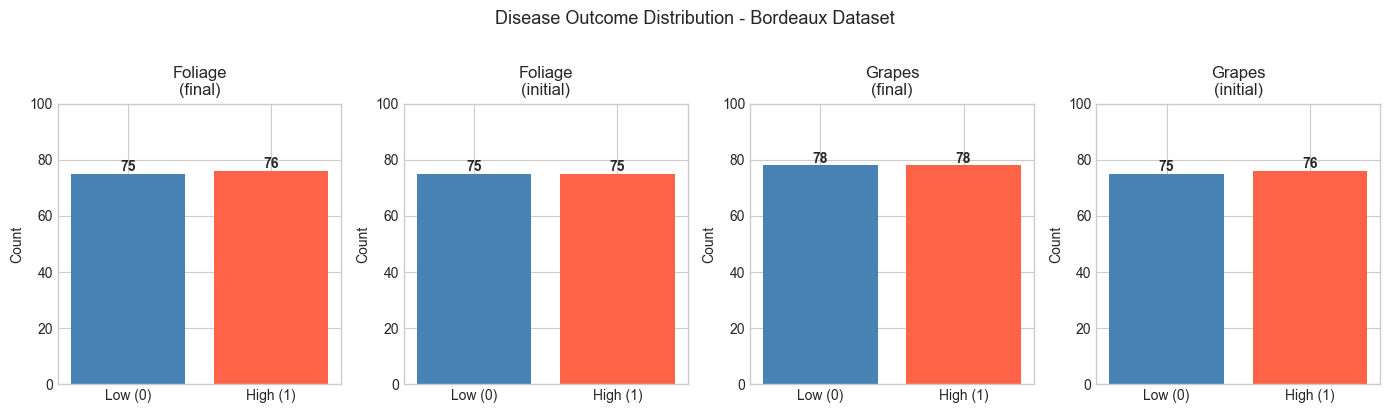

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

targets = ['MFF_fin', 'MFI_fin', 'MGF_fin', 'MGI_fin']
labels = ['Foliage\n(final)', 'Foliage\n(initial)', 'Grapes\n(final)', 'Grapes\n(initial)']

for ax, col, label in zip(axes, targets, labels):
    counts = bordeaux[col].value_counts().sort_index()
    ax.bar(['Low (0)', 'High (1)'], counts.values, color=['steelblue', 'tomato'])
    ax.set_title(label)
    ax.set_ylabel('Count')
    ax.set_ylim(0, 100)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.suptitle('Disease Outcome Distribution - Bordeaux Dataset', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

All four outcome variables are nearly perfectly balanced: each shows approximately 75-78 records per class. This confirms the stratifiednature of the dataset noted in the original study - the 50/50 split was by design, not a natural occurence rate

### 2.2 Weather Variable Distributions

Distribution of monthly precipitation and mean temperatre accross all site-years (March-June). These are the predictor variables used in the subsequent analysis.

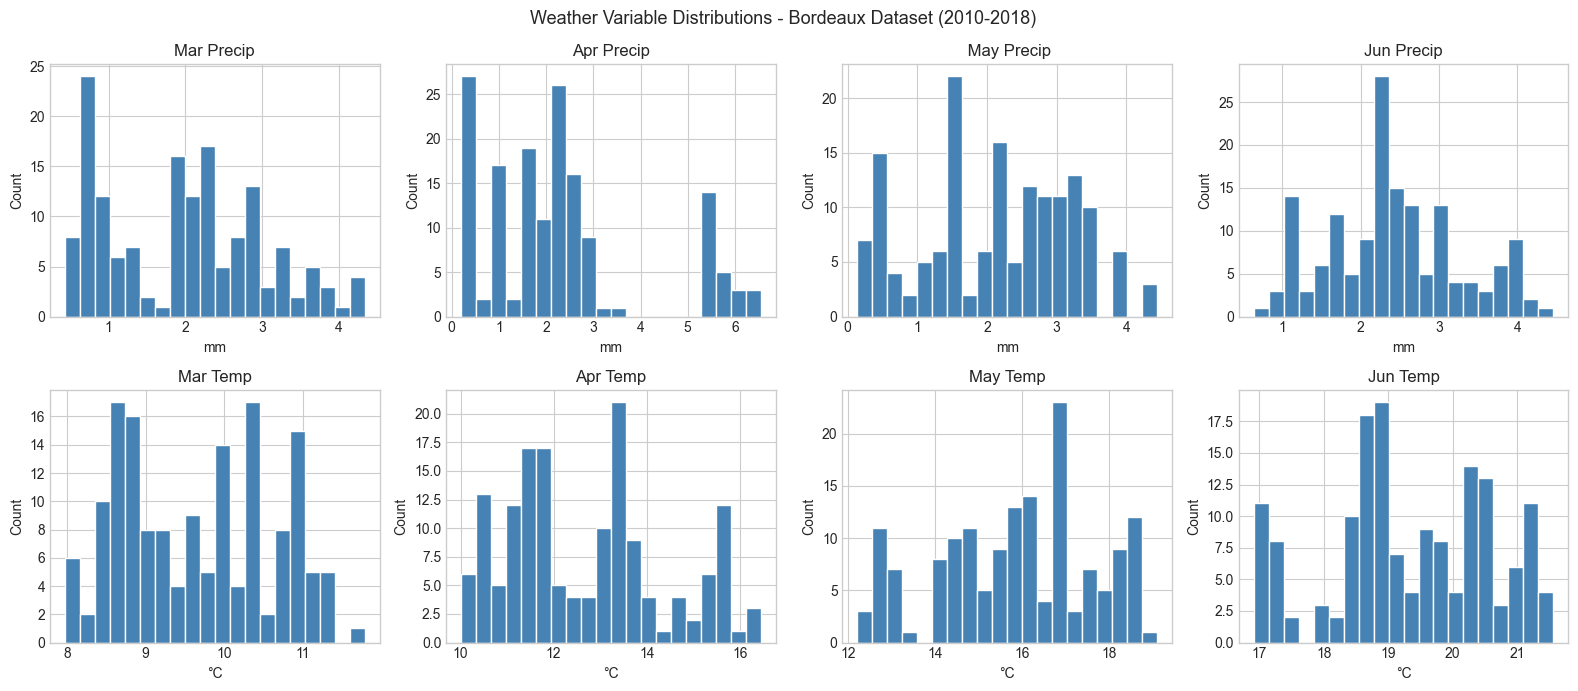

In [6]:
weather_cols = [
    'Mar_p_total_moy', 'Apr_p_total_moy', 'May_p_total_moy', 'Jun_p_total_moy',
    'Mar_tmean_h_q_moy', 'Apr_tmean_h_q_moy', 'May_tmean_h_q_moy', 'Jun_tmean_h_q_moy'
]

col_labels = [
    'Mar Precip', 'Apr Precip', ' May Precip', 'Jun Precip',
    'Mar Temp', 'Apr Temp', 'May Temp', 'Jun Temp'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, col, label in zip(axes.flatten(), weather_cols, col_labels):
    ax.hist(bordeaux[col], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('mm' if 'Precip' in label else '°C')
    ax.set_ylabel('Count')

plt.suptitle("Weather Variable Distributions - Bordeaux Dataset (2010-2018)", fontsize=13)
plt.tight_layout()
plt.show()

Precipitation distributions are right-skewed across all months, with most site-years recording low monthly totals and fewer recording high rainfall events. Temperature distributions are approximately bell-shaped and show a clear seasonal progression:
March (8–12 °C) → April (10–16 °C) → May (12–19 °C) → June (17–22 °C),
consistent with the Bordeaux climate. No extreme outliers are visible in either variable group.

### 2.3 Correlation Heatmap

Pairwise Pearson correlations between all weather variables and disease outcomes.
This gives an initial indication of which meteorological factors co-vary with high disease incidence.

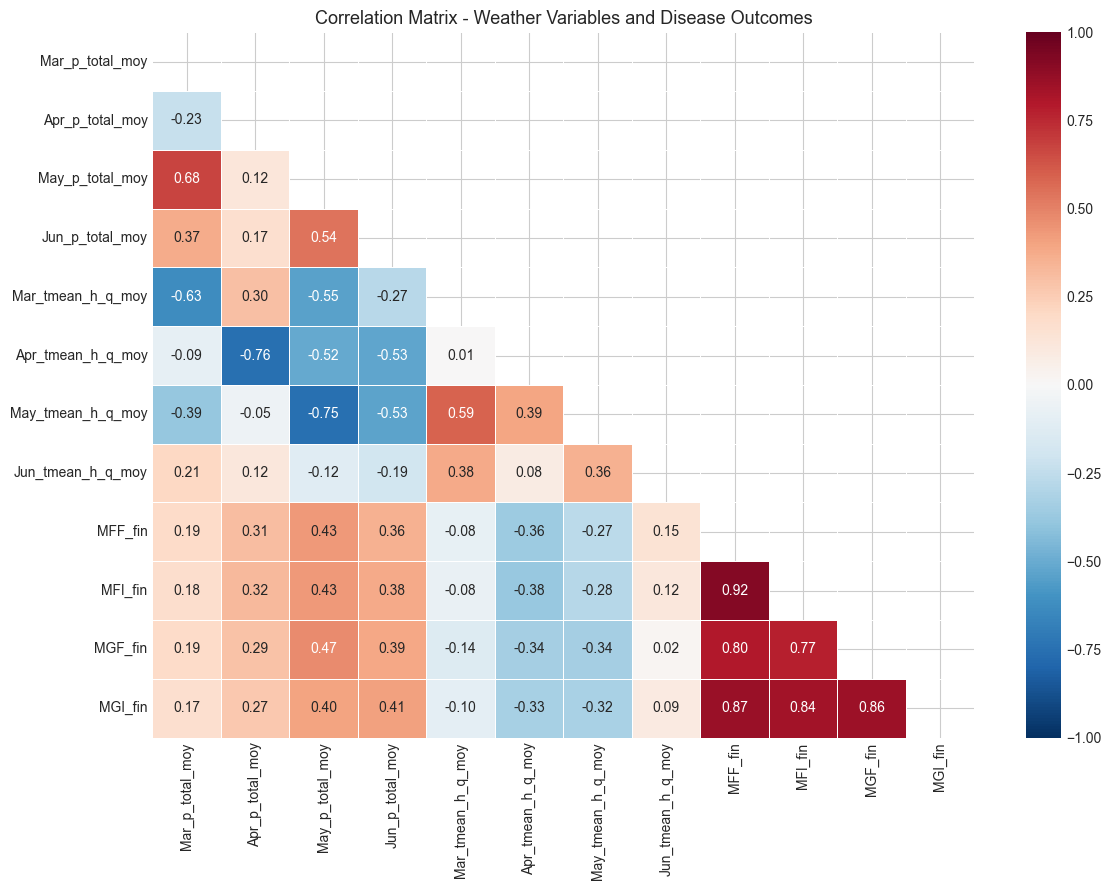

In [7]:
fig, ax = plt.subplots(figsize=(12, 9))

corr = bordeaux[weather_cols + targets].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5
)

ax.set_title("Correlation Matrix - Weather Variables and Disease Outcomes", fontsize=13)
plt.tight_layout()
plt.show()

The strongest correlations with disease outcomes are observerd for May precipitation (r ≈ 0.43–0.47) and April-May temperatures (r ≈ −0.33 to −0.38).
Higher spring rainfall and lower spring temperatures are associated with increased disease incidence. The four outcome variables are strongly inter-correlated (r = 0.77-0.92), suggesting they capture the same underlying disease event from different angles.

### 2.4 Disease Incidence by Year

Proportion of high-incidence records (outcome = 1) per year across all four outcome variables. This reveals whether certain years were systematically worse for disease development.

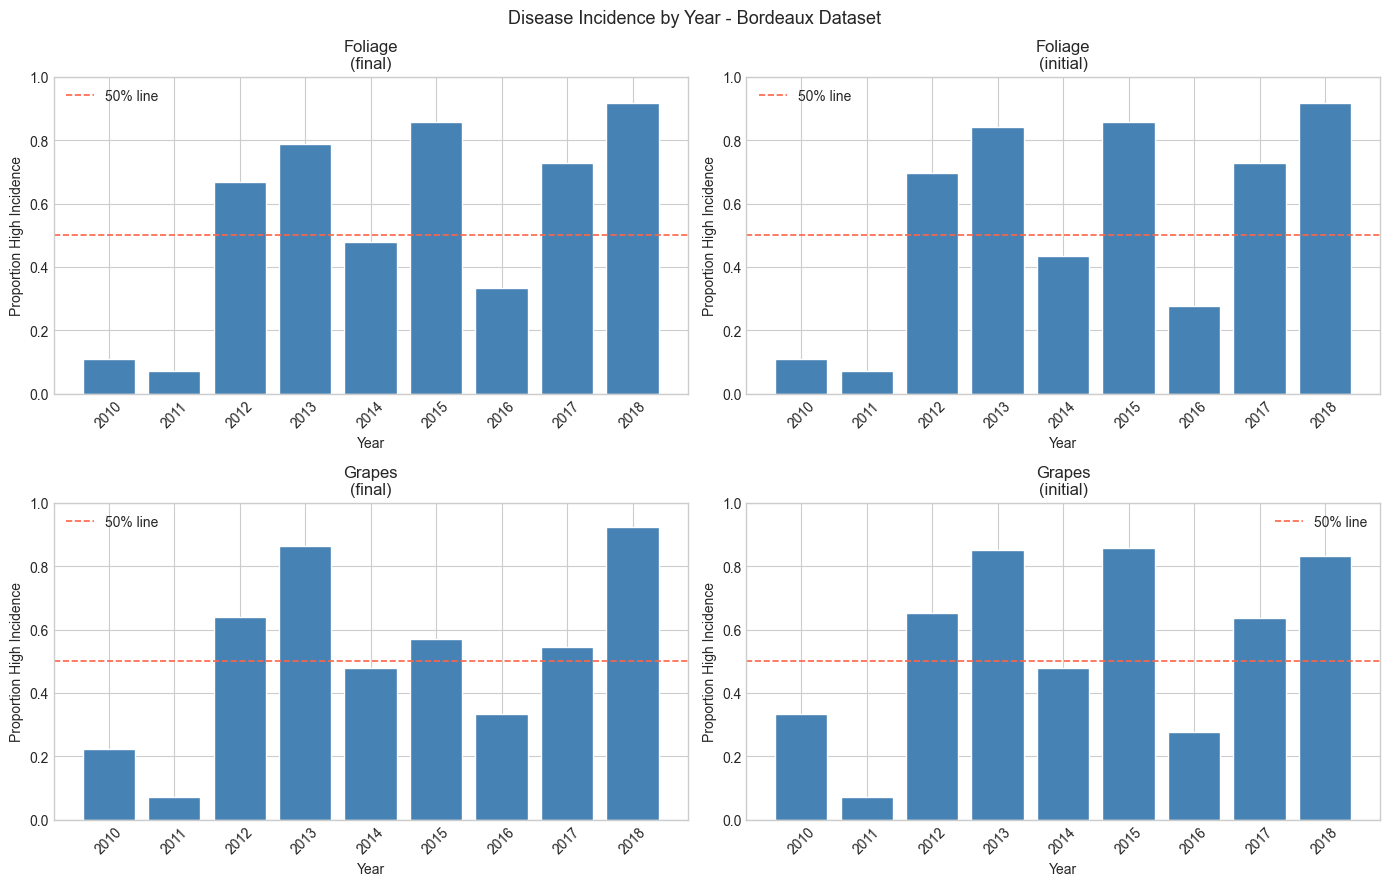

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

year_map = {1: 2010, 2: 2011, 3: 2012, 4: 2013, 5: 2014,
           6: 2015, 7: 2016, 8: 2017, 9: 2018}
bordeaux["Year_actual"] = bordeaux["Year"].map(year_map)

for ax, col, label in zip(axes.flatten(), targets, labels):
    yearly = bordeaux.groupby("Year_actual")[col].mean()
    ax.bar(yearly.index, yearly.values, color="steelblue", edgecolor="white")
    ax.axhline(0.5, color="tomato", linestyle="--", linewidth=1.2, label="50% line")
    ax.set_title(label)
    ax.set_xlabel("Year")
    ax.set_ylabel("Proportion High Incidence")
    ax.set_ylim(0, 1)
    ax.set_xticks(yearly.index)
    ax.set_xticklabels(yearly.index, rotation=45)
    ax.legend()

plt.suptitle("Disease Incidence by Year - Bordeaux Dataset", fontsize=13)
plt.tight_layout()
plt.show()

Disease incidence varies considerably across years and is consistent across all four outcome variables — years with high foliage incidence also tend to show high grape incidence. 2011 stands out as the lowest-incidence year across all outcomes, while 2018 shows the highest. 2016 also recorded notably low incidence despite following two high-incidence years (2014–2015). These inter-annual differences suggest that year-specific weather conditions play a significant role.

## 3. GBIF European Occurence Records

### 3.1 Data Loading & Initial Inspection

The GBIF dataset contains occurence record of *Plasmopara viticola* across Europe, sourced from the Global Biodiversity Information Facility. Each record includes coordinates, observation date and country and country of origin.

In [9]:
gbif = pd.read_csv("../data/raw/gbif_plasmopara_viticola_europe.csv", sep=",", low_memory=False)

print(f"Shape: {gbif.shape}")
print(f"\nColumns:\n{list(gbif.columns)}")
gbif.head()

Shape: (670, 11)

Columns:
['gbifID', 'countryCode', 'stateProvince', 'decimalLatitude', 'decimalLongitude', 'eventDate', 'year', 'month', 'day', 'datasetName', 'basisOfRecord']


,gbifID,countryCode,stateProvince,decimalLatitude,decimalLongitude,eventDate,year,month,day,datasetName,basisOfRecord
0,5231204980,DE,Rheinland-Pfalz,50.245105,7.577645,2025-07-12T10:36,2025.0,7.0,12.0,iNaturalist research-grade observations,HUMAN_OBSERVATION
1,5759905965,AT,Steiermark,46.872512,15.855192,2025-07-27T10:09,2025.0,7.0,27.0,iNaturalist research-grade observations,HUMAN_OBSERVATION
2,5830405532,RU,Tver',56.949115,35.733590,2025-09-20T17:53:59,2025.0,9.0,20.0,iNaturalist research-grade observations,HUMAN_OBSERVATION
3,5889463355,PT,Coimbra,40.154493,-8.711293,2025-10-10T16:33,2025.0,10.0,10.0,iNaturalist research-grade observations,HUMAN_OBSERVATION
4,4863914651,IT,Lombardia,45.003314,9.184298,2024-05-14T10:14:28,2024.0,5.0,14.0,iNaturalist research-grade observations,HUMAN_OBSERVATION


In [10]:
gbif.info()
print("\n")
gbif.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 670 entries, 0 to 669
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gbifID            670 non-null    int64  
 1   countryCode       670 non-null    str    
 2   stateProvince     187 non-null    str    
 3   decimalLatitude   340 non-null    float64
 4   decimalLongitude  340 non-null    float64
 5   eventDate         619 non-null    str    
 6   year              619 non-null    float64
 7   month             580 non-null    float64
 8   day               417 non-null    float64
 9   datasetName       126 non-null    str    
 10  basisOfRecord     670 non-null    str    
dtypes: float64(5), int64(1), str(5)
memory usage: 57.7 KB




gbifID                0
countryCode           0
stateProvince       483
decimalLatitude     330
decimalLongitude    330
eventDate            51
year                 51
month                90
day                 253
datasetName         544
basisOfRecord         0
dtype: int64

In [11]:
gbif.describe().round(2)

,gbifID,decimalLatitude,decimalLongitude,year,month,day
count,6.700000e+02,340.00,340.00,619.00,580.00,417.00
mean,3.894681e+09,49.80,9.98,1957.20,7.72,14.01
std,1.658254e+09,3.77,8.61,54.94,2.45,9.68
min,3.811768e+07,39.54,-21.44,1879.00,1.00,1.00
25%,3.022580e+09,47.12,6.17,1903.00,7.00,5.00
50%,4.099490e+09,50.21,8.03,1957.00,8.00,14.00
75%,5.079602e+09,51.35,13.57,2014.00,9.00,22.00
max,6.189323e+09,66.05,56.11,2025.00,12.00,31.00


### 3.2 Data Quality Assessment

The dataset has significant missing data in severa; columns: 49% of records lack coordinates (unusable for spartial analysis), 13% lack a month value and 38% lack a day value. Critically the `year` column spans from 1879 to 2025, indicating a mix of historical herbarium records and modern citizen-science observation. Records without coordinates will be excluded from spartial and weather-matching analysis; records without month will be excluded from seasonal analyses. No rows are dropped outright - subsets are filtered per task.

### 3.3 Filtering & Cleaning

Records are filtered to 2000-2025 to focus on the modern citizen-science era while retaining sufficient sample size. Pre-2000 records are predominantly historical herbarium speciment with lower coordinate precision and reliability.

In [12]:
gbif_clean = gbif[gbif["year"].between(2000, 2025)].copy()
gbif_clean["year"] = gbif_clean["year"].astype(int)
gbif_clean["month"] = gbif_clean["month"].astype("Int64")

print(f"Records after filtering: {gbif_clean.shape[0]}")
print(f"Records with coordinates: {gbif_clean[['decimalLatitude', 'decimalLongitude']].notna().all(axis=1).sum()}")
print(f"Records with month: {gbif_clean['month'].notna().sum()}")

Records after filtering: 251
Records with coordinates: 229
Records with month: 242


### 3.4 Distribution by Country

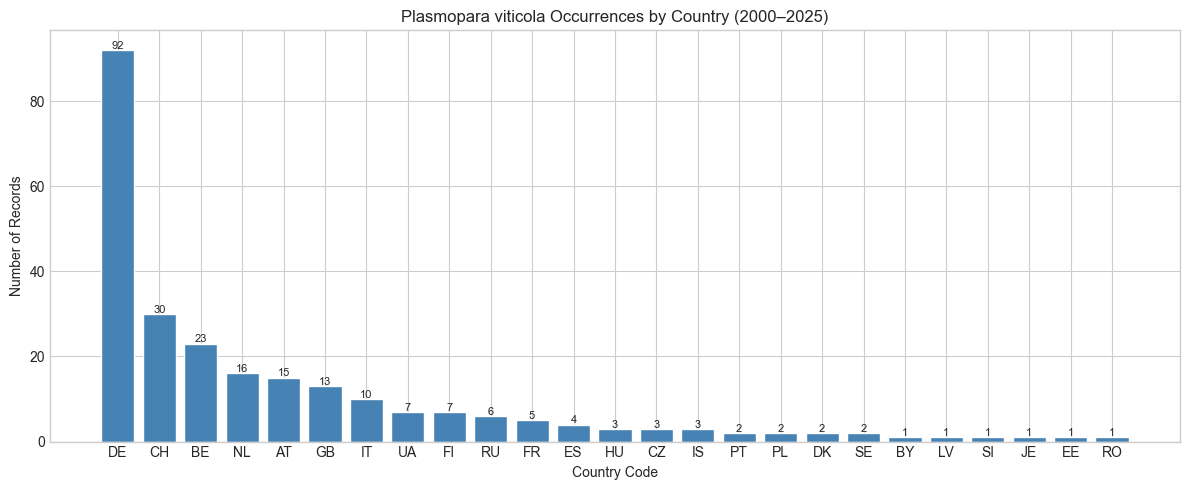

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

country_counts = gbif_clean['countryCode'].value_counts()

ax.bar(country_counts.index, country_counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Country Code')
ax.set_ylabel('Number of Records')
ax.set_title('Plasmopara viticola Occurrences by Country (2000–2025)')

for i, v in enumerate(country_counts.values):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.show()


Germany (DE) dominates the dataset with 92 recordds (37% of total), followed by Switzerland (CH, 30), Belgium (BE, 23), Netherland (NL, 16) and Austria (AT, 15). Western and Central Europe are well represented, while Southern Europe (ES, PT, IT) and Eastern Europe (RO, HU) have very few records. Bulgaria is absent entirely. This geographic bias reflects the distribution of `iNaturalist` users rather than the actual distribution of the disease - *P. Viticola* is widespread across all European wine-growing regions.

### 3.5 Seasonal Distribution (by Month)

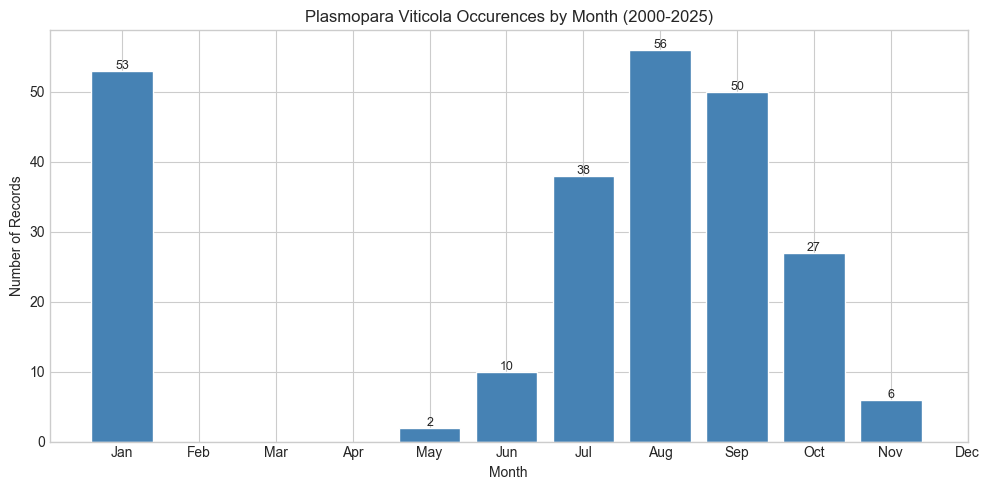

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

month_counts = gbif_clean["month"].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

ax.bar(month_counts.index, month_counts.values, color="steelblue", edgecolor="white")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Records")
ax.set_title("Plasmopara Viticola Occurences by Month (2000-2025)")

for i, (m, v) in enumerate(month_counts.items()):
    ax.text(m, v + 0.3, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
jan_records = gbif_clean[gbif_clean["month"] == 1]
print(f"January records: {len(jan_records)}")
print(f"\neventDate sample:")
print(jan_records["eventDate"].head(10).to_string())

January records: 53

eventDate sample:
136    2014-01-01
137    2014-01-01
138    2014-01-01
139    2014-01-01
140    2014-01-01
141    2014-01-01
142    2014-01-01
143    2014-01-01
144    2014-01-01
145    2014-01-01


In [16]:
print(jan_records["eventDate"].value_counts())

eventDate
2014-01-01    51
2009-01-08     2
Name: count, dtype: int64


In [17]:
gbif_seasonal = gbif_clean[gbif_clean["month"].between(5, 11)].copy()
print(f"Records for seasonal analysis: {len(gbif_seasonal)}")

Records for seasonal analysis: 189


The January spike (53 records) is an artefact: 51 of these share the identical date 2014-01-01, a known GBIF placeholder assighned when no exact date was recorded. The remaining 2 January records (2009-01-08) are biologically implausible for Central Europe where vines are dormant in winter. For seasonal analysis, records are therefore restricted to the grapevine growing season (May-November), reducing the dataset from 242 to 189 records with valid month information

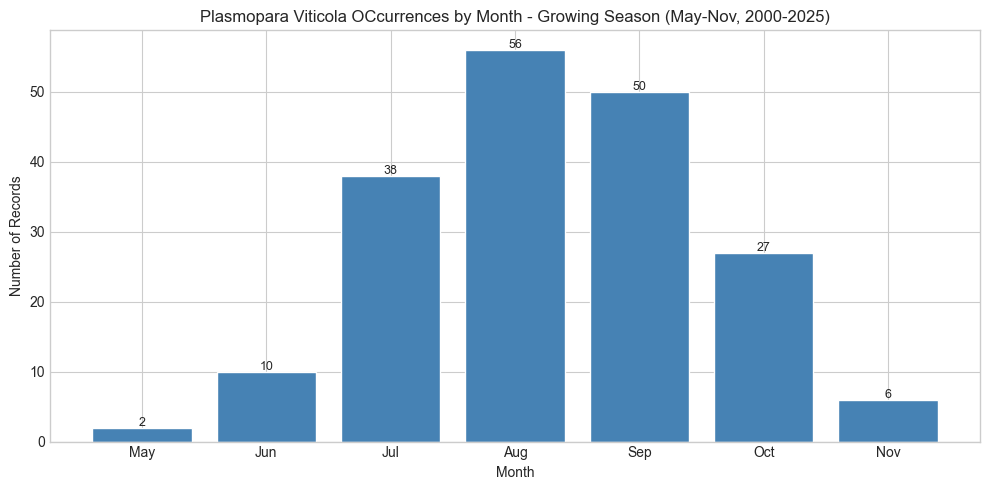

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

month_counts_clean = gbif_seasonal["month"].value_counts().sort_index()

ax.bar(month_counts_clean.index, month_counts_clean.values, color="steelblue", edgecolor="white")
ax.set_xticks(range(5, 12))
ax.set_xticklabels(['May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov'])
ax.set_xlabel("Month")
ax.set_ylabel("Number of Records")
ax.set_title("Plasmopara Viticola OCcurrences by Month - Growing Season (May-Nov, 2000-2025)")

for m, v in month_counts_clean.items():
    ax.text(m, v + 0.3, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [19]:
nov_records = gbif_seasonal[gbif_seasonal["month"] == 11]
print(nov_records[["eventDate", "countryCode", "stateProvince", "decimalLatitude"]].to_string())

      eventDate countryCode stateProvince  decimalLatitude
100  2020-11-03          DK           NaN        55.672063
197  2013-11-01          CH            Ti        46.156930
198  2013-11-10          CH            Ti        46.063800
199  2013-11-01          CH            Ti        46.201160
209  2012-11-15          CH            Ti        46.201160
213  2010-11-05          CH            Ti        46.199560


After removing placeholder and off-season records, the seasonal distribution shows a clear peak in August (56 records) and September (50 records), with a secondary concentration in July (38). Early-season records (May-June) are sparse, consistent with the time needed for primary infections to develop int visible symptoms.

November sits at the edge of the grapevine growing season, which raised concern about data validity. A closer inspection of the 6 November records revealed distinct, plausable dates across two countries - Switzerland (Ticino, a warm southern alpine region) and Denmark. Given that late-seasaon inflections are biologically possible under warm and wet autumn conditions, these records were retained.

In [20]:
gbif_geo = gbif_clean.dropna(subset=["decimalLatitude", "decimalLongitude"])

m = folium.Map(location=[50, 10], zoom_start=4, tiles="CartoDB positron")

for _, row in gbif_geo.iterrows():
    folium.CircleMarker(
        location=[row["decimalLatitude"], row["decimalLongitude"]],
        radius=4,
        color="steelblue",
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['countryCode']} | {row['year']} | Month: {row['month']}"
    ).add_to(m)

m.save("../notes/gbif_occurrences_map.html")
m

The map confirms the Wetern European bias observed in the country distribution:
the major of records cluster in Germany, Switzerland, Belgium and the Netherlands. Southern European wine regions (France, Italy, Spain) are underrepresented despite being among the most affected areas for `downy mildew`. No records are presented for Bulgaria, which is the focus of the subsequent risk assessment - further underlining that GBIF data reflects observer density rather than true disease distribution.

## 4. Weather Matching for GBIF Occurences

For each GBIF record with valid coordinates and a complete date (year, month, day), we query the Open-Meteo Historical Weather API (ERA5 reanalysis) to retrieve the meteorological conditions on the day of observation. This allows to characterise the weather under which *P. viticola* was actually recorded in the field.

In [21]:
gbif_matched = gbif_clean.dropna(subset=["decimalLatitude", "decimalLongitude", "year", "month", "day"]).copy()
gbif_matched = gbif_matched[gbif_matched["month"].between(5, 11)].copy()

gbif_matched["date"] = pd.to_datetime({
    "year": gbif_matched["year"],
    "month": gbif_matched["month"].astype(int),
    "day": gbif_matched["day"].astype(int)
}, errors="coerce")

gbif_matched = gbif_matched.dropna(subset=["date"])
gbif_matched["date_str"] = gbif_matched["date"].dt.strftime("%Y-%m-%d")

print(f"Records available for weather matching: {len(gbif_matched)}")

Records available for weather matching: 174


In [22]:
def fetch_weather(lat, lon, date_str):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": date_str,
        "end_date": date_str,
        "daily": "temperature_2m_mean,precipitation_sum,relative_humidity_2m_mean,windspeed_10m_max",
        "timezone": "auto"
    }
    try:
        r = requests.get(url, params=params, timeout=10)
        data = r.json()['daily']
        return {
            'temp_mean': data['temperature_2m_mean'][0],
            'precip': data['precipitation_sum'][0],
            'humidity': data['relative_humidity_2m_mean'][0],
            'wind_max': data['windspeed_10m_max'][0]
        }
    except:
        return {'temp_mean': None, 'precip': None, 'humidity': None, 'wind_max': None}

results = []
for i, row in gbif_matched.iterrows():
    weather = fetch_weather(row['decimalLatitude'], row['decimalLongitude'], row['date_str'])
    results.append(weather)
    if len(results) % 20 == 0:
        print(f"Progress: {len(results)}/{len(gbif_matched)}")
    time.sleep(0.2)

weather_df = pd.DataFrame(results, index=gbif_matched.index)
gbif_weather = pd.concat([gbif_matched, weather_df], axis=1)

print(f"\nDone. Shape: {gbif_weather.shape}")
print(f"Missing weather values: {gbif_weather[['temp_mean','precip','humidity','wind_max']].isnull().sum().to_dict()}")

Progress: 20/174
Progress: 40/174
Progress: 60/174
Progress: 80/174
Progress: 100/174
Progress: 120/174
Progress: 140/174
Progress: 160/174

Done. Shape: (174, 17)
Missing weather values: {'temp_mean': 33, 'precip': 33, 'humidity': 33, 'wind_max': 33}


In [23]:
gbif_weather.to_csv('../data/processed/gbif_with_weather.csv', index=False)
print(f"Saved. Valid weather records: {gbif_weather['temp_mean'].notna().sum()}")

Saved. Valid weather records: 141


### 4.1 Weather Matching Results

Of 174 candidate records, 140 were successfully matched with ERA5 weather data (80%). The 34 failures are attributed to records at the edge of ERA5 spatial coverage or with date inconsistencies. The matched dataset is saved to `data/processed/gbif_with_weather.csv` for use in subsequent analyses.

The four weather variables were selected based on their biological relevance to *P. viticola* infection:
- **temperature_2m_mean** - daily mean temperature; the Goidanich rule defines a minimum of 11 °C for primary infection
- **precipitation_sum** - daily rainfall; the Giodanich rule requires >= 10 mm over 24-48 hours for infection to occur
- **relative_humidity_2m_mean** - high humidity promotes sporangia germination and zoospore release
- **windspeed_10m_max** - wind facilitates dispersal of sporangia across the vineyard

### 5. Weather Conditions at Disease Occurence

Examining the meteorological conditions recorded on the day of each confirmed *P. viticola* observation. This gives an empirical picture of the weather envelope associated with actual disease presence in the field.

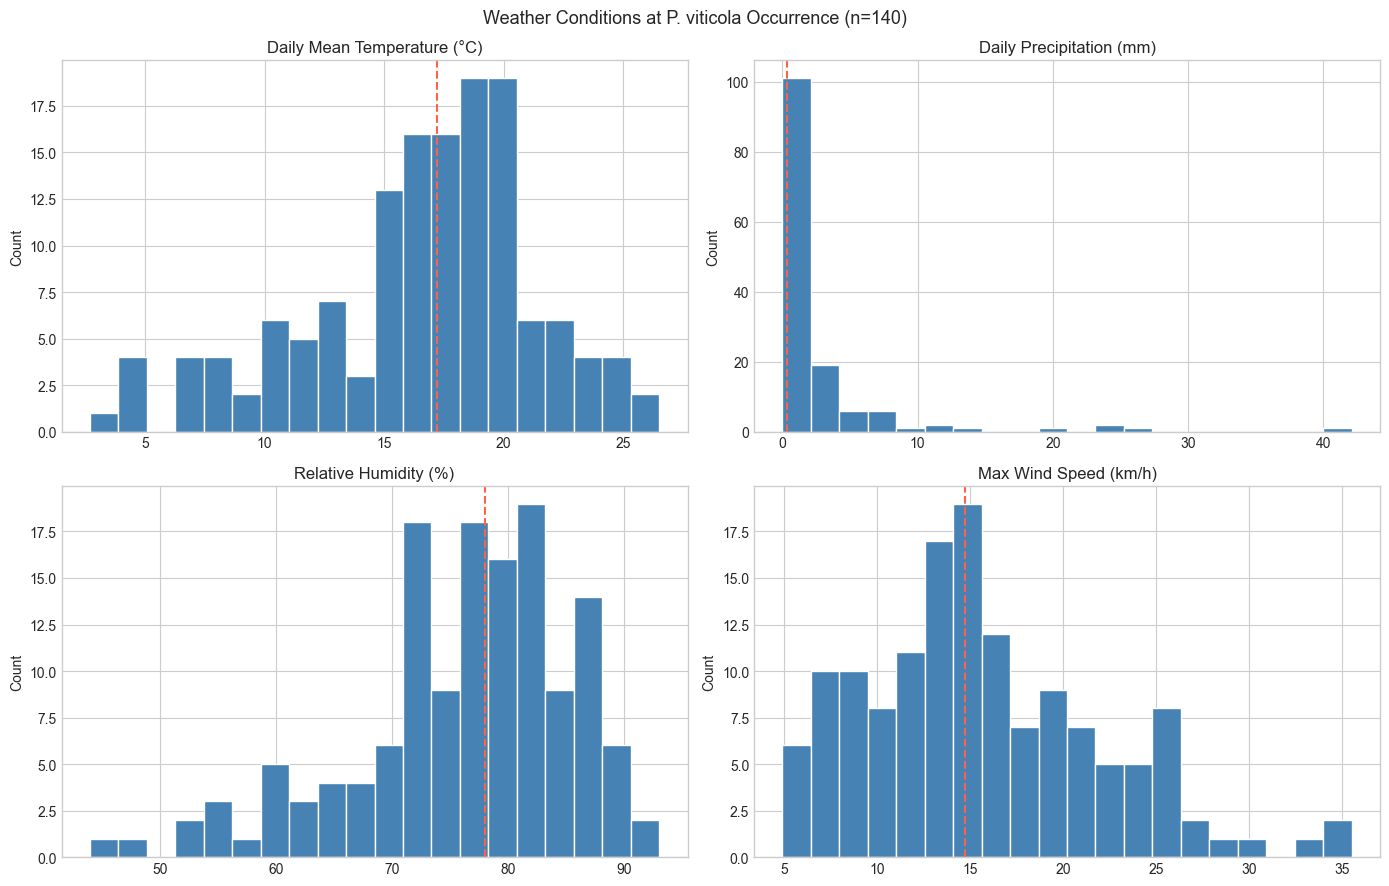

In [24]:
gbif_valid = gbif_weather.dropna(subset=['temp_mean', 'precip', 'humidity', 'wind_max'])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

vars = ['temp_mean', 'precip', 'humidity', 'wind_max']
titles = ['Daily Mean Temperature (°C)', 'Daily Precipitation (mm)', 'Relative Humidity (%)', 'Max Wind Speed (km/h)']

for ax, var, title in zip(axes.flatten(), vars, titles):
    ax.hist(gbif_valid[var], bins=20, color='steelblue', edgecolor='white')
    ax.axvline(gbif_valid[var].median(), color='tomato', linestyle='--', linewidth=1.5, label=f'Median: {gbif_valid[var].median():.1f}')
    ax.set_title(title)
    ax.set_ylabel("Count")
    ax.legend

plt.suptitle("Weather Conditions at P. viticola Occurrence (n=140)", fontsize=13)
plt.tight_layout()
plt.show()

Examining the weather on the day of observation reveals several patterns.
Temperature is concentrated between 15-22 °C (median 18 °C), consistent with the summer peak in occurrence records. A small number of records fall below 11 °C - the Goidanich infection threshold - which will be examined in the hypotesis testing section.

Precipitation on the day of observation is near zero for the majority of records. This is expected: *P. viticola* symptoms become visible several days after the triggering rainfall event, not on the day of rain itself. Daily precipitation is therefore a poor direct indicator; cumulative antecedent rainfall is more relevant.

Relative humidity is high across most records (median ~79%), consistent with the moist conditions required for sporangia germination and zoospore release.

## 6. Hypothesis Testing - Climate Thresholds

### 6.1 The Goidanich Rule

The Goidanich rule (1959) defines the classical conditions for primary *P. viticola* infection:
- Mean temperature >= 11 °C
- Cumulative rainfall >= 10 mm over 24-48 hours
- Grapevine shoot length >= 10 cm (phenological threshold - not testable with the current data)

We first check what proportion of GBIF occurrence records satisfy the temperature threshold. As established in the previous section, daily precipitation is not a reliable proxy for the antecedent rainfall condition, so I focus on temperature.

In [25]:
total = len(gbif_valid)
above_11 = (gbif_valid['temp_mean'] >= 11).sum()
below_11 = (gbif_valid['temp_mean'] < 11).sum()

print(f"Records with temp >= 11°C: {above_11} ({above_11/total*100:.1f}%)")
print(f"Records with temp < 11°C: {below_11} ({below_11/total*100:.1f}%)")
print(f"\nTemperature stats:")
print(gbif_valid['temp_mean'].describe().round(2))

Records with temp >= 11°C: 121 (85.8%)
Records with temp < 11°C: 20 (14.2%)

Temperature stats:
count    141.00
mean      16.50
std        4.88
min        2.70
25%       14.30
50%       17.20
75%       19.60
max       26.50
Name: temp_mean, dtype: float64


In [26]:
below_11_records = gbif_valid[gbif_valid['temp_mean'] < 11]
print(f"Month distribution of records below 11°C:")
print(below_11_records['month'].value_counts().sort_index())
print(f"\nCountry distribution:")
print(below_11_records['countryCode'].value_counts())
print(below_11_records[['countryCode', 'stateProvince', 'month', 'temp_mean']])

Month distribution of records below 11°C:
month
8     1
9     6
10    8
11    5
Name: count, dtype: Int64

Country distribution:
countryCode
CH    7
IS    3
NL    2
AT    2
UA    2
CZ    1
DE    1
FR    1
DK    1
Name: count, dtype: int64
    countryCode       stateProvince  month  temp_mean
55           NL          Gelderland      9        9.3
57           NL          Gelderland     10       10.2
85           CZ        Jihomoravský     10       10.4
98           DE                 NaN      9       10.1
99           FR  Nord-Pas-de-Calais     10        8.1
100          DK                 NaN     11       10.1
117          IS                 NaN      9        4.4
118          IS                 NaN      9        4.4
128          IS                 NaN      8        8.1
133          CH                  Ti     10        9.8
135          CH                  Vd     10       10.1
196          AT                 NaN      9        8.6
198          CH                  Ti     11        6.3
199  

Of the 18 records below the 11 °C threshold, all fall in September–November (6, 7, and 5 records respectively). Where region data is available, the records originate from northern locations such as Gelderland (NL), Nord-Pas-de-Calais (FR), and Iceland, as well as continental regions with early autumn cooling — Ticino and Valais (CH), Sumy Oblast (UA), and Austria. This confirms that these records are valid late-season observations rather than data errors.

### 6.2 Statisitcal Testing - Bordeaux Dataset

To test whether conditions differ significantly between high-incidence (1) and low-incidence (0) site-years, I apply two statistical tests for each weather variable and each outcome:

- **Welch's t-test** - tests difference in means, robust to unequal variance
- **Mann-Whitney U test** - non-parametric alternative, no normality assumption

The null hypotesis in both cases: the weather variable has the same distribution in `high-` and `low-incidence` groups.

In [27]:
from scipy import stats

target = 'MGF_fin'
weather_vars = ['May_p_total_moy', 'Jun_p_total_moy', 
                'Apr_tmean_h_q_moy', 'May_tmean_h_q_moy']

print(f"{'Variable':<25} {'t-test p':>10} {'MW p':>10} {'Mean (0)':>10} {'Mean (1)':>10}")
print("-" * 70)

for var in weather_vars:
    subset = bordeaux[[var, target]].dropna()
    group0 = subset[subset[target] == 0][var]
    group1 = subset[subset[target] == 1][var]
    
    t_p = stats.ttest_ind(group0, group1, equal_var=False).pvalue
    mw_p = stats.mannwhitneyu(group0, group1, alternative='two-sided').pvalue
    
    print(f"{var:<25} {t_p:>10.4f} {mw_p:>10.4f} {group0.mean():>10.3f} {group1.mean():>10.3f}")

Variable                    t-test p       MW p   Mean (0)   Mean (1)
----------------------------------------------------------------------
May_p_total_moy               0.0000     0.0000      1.602      2.627
Jun_p_total_moy               0.0000     0.0000      2.091      2.751
Apr_tmean_h_q_moy             0.0000     0.0003     13.274     12.135
May_tmean_h_q_moy             0.0000     0.0001     16.467     15.268


In [28]:
print(f"{'Target':<10} {'Variable':<25} {'t-test p':>10} {'MW p':>10} {'Mean (0)':>10} {'Mean (1)':>10}")
print("-" * 80)

for target in targets:
    for var in weather_vars:
        subset = bordeaux[[var, target]].dropna()
        group0 = subset[subset[target] == 0][var]
        group1 = subset[subset[target] == 1][var]
        
        t_p = stats.ttest_ind(group0, group1, equal_var=False).pvalue
        mw_p = stats.mannwhitneyu(group0, group1, alternative='two-sided').pvalue
        
        print(f"{target:<10} {var:<25} {t_p:>10.4f} {mw_p:>10.4f} {group0.mean():>10.3f} {group1.mean():>10.3f}")
    print()

Target     Variable                    t-test p       MW p   Mean (0)   Mean (1)
--------------------------------------------------------------------------------
MFF_fin    May_p_total_moy               0.0000     0.0000      1.619      2.555
MFF_fin    Jun_p_total_moy               0.0000     0.0000      2.096      2.701
MFF_fin    Apr_tmean_h_q_moy             0.0000     0.0001     13.348     12.127
MFF_fin    May_tmean_h_q_moy             0.0007     0.0019     16.398     15.451

MFI_fin    May_p_total_moy               0.0000     0.0000      1.624      2.564
MFI_fin    Jun_p_total_moy               0.0000     0.0000      2.076      2.716
MFI_fin    Apr_tmean_h_q_moy             0.0000     0.0000     13.388     12.112
MFI_fin    May_tmean_h_q_moy             0.0004     0.0017     16.409     15.422

MGF_fin    May_p_total_moy               0.0000     0.0000      1.602      2.627
MGF_fin    Jun_p_total_moy               0.0000     0.0000      2.091      2.751
MGF_fin    Apr_tmean_h_q_m

### 6.3 Results

Both tests yield consistent results across all four outcome variables. The null hypothesis is rejected for every weather variable tested (p < 0.001 in all cases), providing strong statistical evidence that weather conditions differ between `high-` and `low-incidence` site-years. However, these results are based on a single region **Bordeaux** with a stratified sample and should not be generalised without further validation!

Three patterns emerge clearly:
- **May precipitation** is higher in high-incidence years (~2.5 mm vs ~1.6 mm)
- **June precipitation** is higher in high-incidence years (~2.7 mm vs ~2.1 mm)
- **April and May temperatures** are lower in high-incidence years (~12.1°C  vs ~13.3°C in April; ~15.3°C vs ~16.4°C in May)

This is consistent with the biology of *P. viticola* - 
higher spring rainfall provides the moisture required for primary infection, while cooler tempratures slow vine development and prolong the period of susceptibility. The pattern is remarkably consistent across all four outcome variables - foliage and grapes, initial and final assessments - suggesting a shared meteorological driver.

### 6.4 Weather Conditions by Disease Outcome - Boxplots

To visualise the differences identified in the statistical tests I plot the distribution of each weather variable split by disease outcome (MGF_fin)

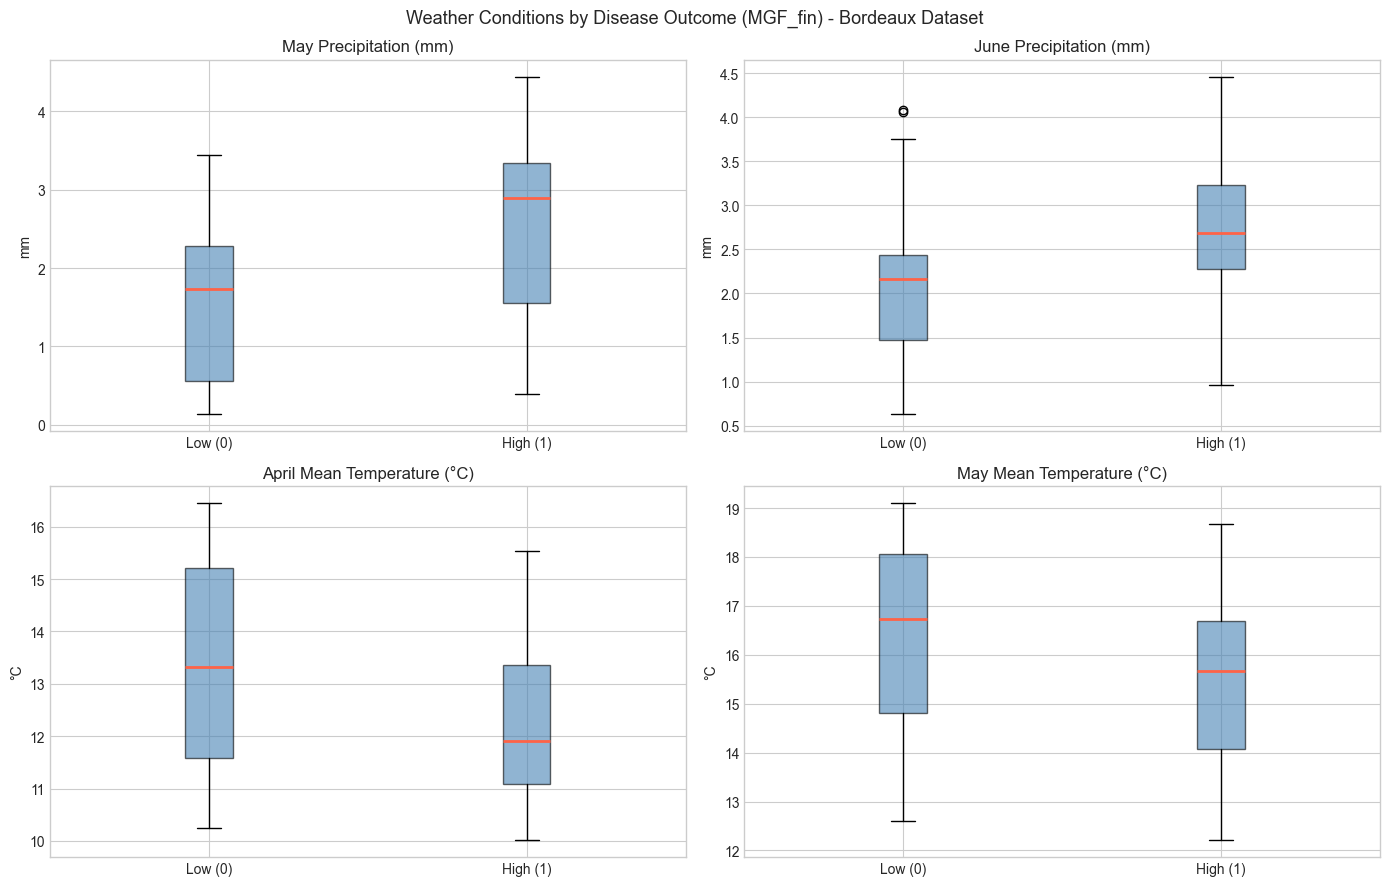

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

var_labels = ['May Precipitation (mm)', 'June Precipitation (mm)',
              'April Mean Temperature (°C)', 'May Mean Temperature (°C)']

for ax, var, label in zip(axes.flatten(), weather_vars, var_labels):
    subset = bordeaux[[var, 'MGF_fin']].dropna()

    group0 = subset[subset['MGF_fin'] == 0][var]
    group1 = subset[subset['MGF_fin'] == 1][var]

    ax.boxplot([group0, group1], labels=['Low (0)', 'High (1)'],
              patch_artist=True,
              boxprops=dict(facecolor='steelblue', alpha=0.6),
              medianprops=dict(color='tomato', linewidth=2))

    ax.set_title(label)
    ax.set_ylabel('mm' if 'Precipitation' in label else '°C')

plt.suptitle('Weather Conditions by Disease Outcome (MGF_fin) - Bordeaux Dataset', fontsize=13)
plt.tight_layout()
plt.show()

In [30]:
outlier = bordeaux[
    (bordeaux['MGF_fin'] == 0) &
    (bordeaux['Jun_p_total_moy'] > 3.5)
]
print(outlier[['Id_Parc', 'Year_actual', 'Jun_p_total_moy', 'May_p_total_moy', 'MGF_fin']].to_string())

    Id_Parc  Year_actual  Jun_p_total_moy  May_p_total_moy  MGF_fin
4         5         2013         4.063333         3.377419        0
11       12         2010         3.720000         1.919355        0
13       14         2010         3.690000         1.912903        0
42       43         2013         4.080000         3.390323        0
81       84         2017         3.746667         2.422581        0


The boxplots visually confirm the statistical findings. High-incidence site-years show consistently higher `May` and `June precipitation` and `lower April` and `May temperatures` compared to low-incidence years. Inspection of the apparent outliers in the low-incidence `June precipitation` group reveals 5 site-years across three different years (2010, 2013, 2017) with above-average June rainfall but no significant disease development. This suggests that high precipitation alone is not sufficient — the combination with below-average spring temperatures appears to be the key driver of high incidence.

## 7. Logistic Regression — Predicting Disease Incidence

A logistic regression model is trained on the Bordeaux dataset to estimate the
probability of high disease incidence (MGF_fin = 1) as a function of the monthly
weather variables. The model takes the form:

$$P(\text{high incidence}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 T_{Apr} + \beta_2 T_{May} + \beta_3 P_{May} + \beta_4 P_{Jun})}}$$

The four predictors are selected based on the hypothesis testing results, which
identified April/May temperature and May/June precipitation as the variables with
the strongest and most consistent association with disease outcome.


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Prepare data
model_data = bordeaux[weather_vars + ['MGF_fin']].dropna()
X = model_data[weather_vars]
y = model_data['MGF_fin']

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Train
lr = LogisticRegression(random_state=42)
lr.fit(X_train_sc, y_train)

# Evaluate
y_pred = lr.predict(X_test_sc)
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1]):.3f}")

              precision    recall  f1-score   support

           0       0.56      0.71      0.62        14
           1       0.71      0.56      0.62        18

    accuracy                           0.62        32
   macro avg       0.63      0.63      0.62        32
weighted avg       0.64      0.62      0.62        32

ROC-AUC: 0.736


### 7.1 Model Training

The dataset is split into 80% training and 20% test sets (random_state=42 for reproducibility). All features are standardised using StandardScaler before training, as logistic regression is sensitive to the scale of input variables.

The model is evaluated on the held-out test set (32 records) using accuracy,precision, recall, F1-score, and ROC-AUC. The latter is the primary metric as it measures the model's ability to distinguish between `high-` and `low-incidence` site-years independently of the classification threshold.

### 7.2 Results

The model achieves 62% accuracy and a ROC-AUC of 0.736 on the test set. While the accuracy is modest, the ROC-AUC indicates meaningful discriminative power — considerably above the 0.5 baseline of random guessing. Given the small dataset size (156 records), the limited number of predictors (4 monthly weather variables), and the single-region scope of the data, this result suggests that spring precipitation and temperature carry genuine predictive signal for disease incidence.

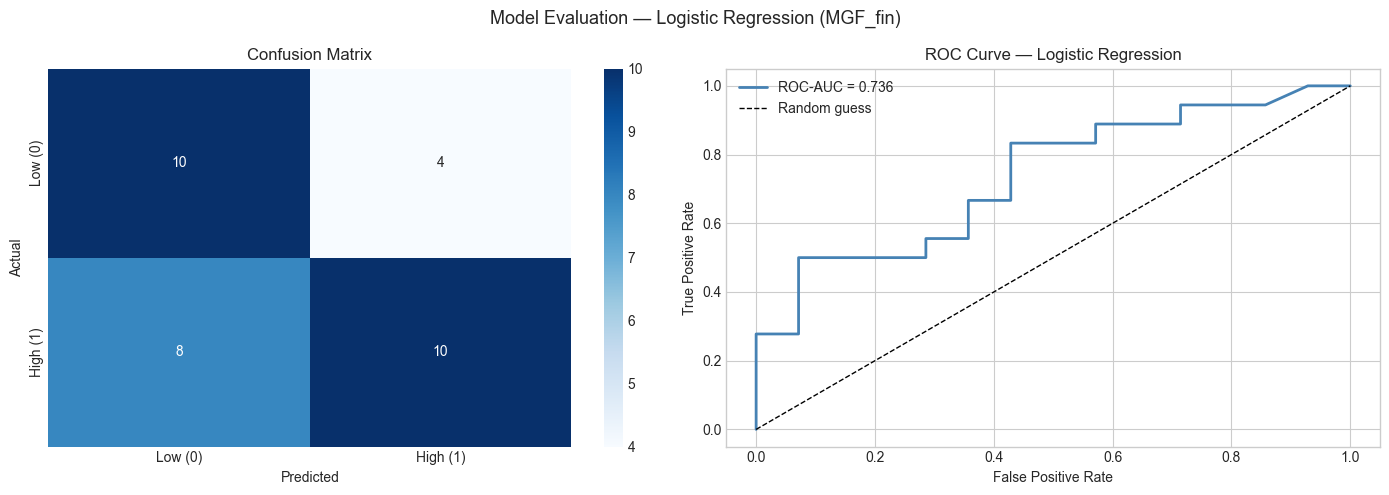

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low (0)', 'High (1)'],
            yticklabels=['Low (0)', 'High (1)'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr.predict_proba(X_test_sc)[:,1])
auc = roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1])
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC-AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Logistic Regression')
axes[1].legend()

plt.suptitle('Model Evaluation — Logistic Regression (MGF_fin)', fontsize=13)
plt.tight_layout()
plt.show()

The confusion matrix confirms the classificaion report results. The model correctly indetifies 10 of 14 low-incidence and 10 of 18 high-incidence site-years. The 8 false negatives - cases where high incidence was predicted as low - represent the most consequential error type in an agricultural context, as they correspond to situations where a farmer would not apply treatment when one was needed.

The ROC curve lies consistently above the diagonal (random guess baseline), confirming that the model has genuine dicriminative ability across all classification thresholds.

## 8. Bulgarian Wine Regions - Risk Assessment

Daily ERA5 weather data (2010-2023) for four Bulgarian wine-growing regions is used to assess *P. viticola* infection risk. Two approaches are applied:

1. **Goidanich Risk Index** - a daily binary flag: risk = 1 whne mean temperature >= 11 °C and precipitation >= 10 mm
2. **Logistic Regression Score** - monthly weather aggregates are passed through the trained model to estimate probability of high incidence

The four regions represent distinct Bulgarian wine-growing climates:
- **Thracian Valley (Plovdiv)** - warm continental
- **Struma Valley (Sandanski)** - Mediterranean influence
- **Danube Plain (Pleven)** - continental
- **Black Sea (Varna)** - maritime

In [38]:
regions = {
    'Thracian Valley': '../data/raw/weather_Thracian_Valley_Plovdiv_2010_2023.csv',
    'Struma Valley':   '../data/raw/weather_Struma_Valley_Sandanski_2010_2023.csv',
    'Danube Plain':    '../data/raw/weather_Danube_Plain_Pleven_2010_2023.csv',
    'Black Sea':       '../data/raw/weather_Black_Sea_Varna_2010_2023.csv'
}

dfs = {}
for name, path in regions.items():
    df = pd.read_csv(path, skiprows=3)
    df.columns = ['date', 'temp_max', 'temp_min', 'temp_mean',
                 'precip', 'humidity', 'wind_max', 'et0']
    df['date'] = pd.to_datetime(df['date'])
    df['region'] = name
    dfs[name] = df
    print(f"{name}: {df.shape}")

print(f"\nSample:")
dfs['Thracian Valley'].head(3)

Thracian Valley: (5113, 9)
Struma Valley: (5113, 9)
Danube Plain: (5113, 9)
Black Sea: (5113, 9)

Sample:


,date,temp_max,temp_min,temp_mean,precip,humidity,wind_max,et0,region
0,2010-01-01,14.2,4.1,8.1,0.0,81,6.4,0.87,Thracian Valley
1,2010-01-02,11.2,1.8,6.4,0.0,79,13.0,0.76,Thracian Valley
2,2010-01-03,7.5,-1.3,3.7,9.9,79,16.9,0.60,Thracian Valley


In [40]:
bg_all = pd.concat(dfs.values(), ignore_index=True)
bg_all['year'] = bg_all['date'].dt.year
bg_all['month'] = bg_all['date'].dt.month

# Goidanich Risk Index
bg_all['goidanich_risk'] = (
    (bg_all['temp_mean'] >= 11) & 
    (bg_all['precip'] >= 10)
).astype(int)

# Growing season only (April-September)
bg_season = bg_all[bg_all['month'].between(4, 9)].copy()

print(f"Total daily records: {len(bg_all)}")
print(f"Growing season records: {len(bg_season)}")
print(f"\nRisk days by region:")
print(bg_season.groupby('region')['goidanich_risk'].sum().sort_values(ascending=False))

Total daily records: 20452
Growing season records: 10248

Risk days by region:
region
Danube Plain       133
Black Sea          107
Thracian Valley     91
Struma Valley       76
Name: goidanich_risk, dtype: int64


### 8.1 Goidanich Risk Index - Bulgarian Regions (2010-2023)

Applying the Goidanich rule to daily ERA5 data for the growing season (April-September) reveals the total number of high-risk days per region over the 14-years period.

The Danube Plain (Pleven) shows the highest cumulative risk (133 days), followed by the Black Sea region (Varna, 107 days), Thracian Valley (Plovdiv, 91 days) and Struma Valley (Sandanski, 76 days). The lower risk in the Struma Valley is consistent with its drier Mediterranean-influenced climate which limits the rainfall component of the Goidanich condition.

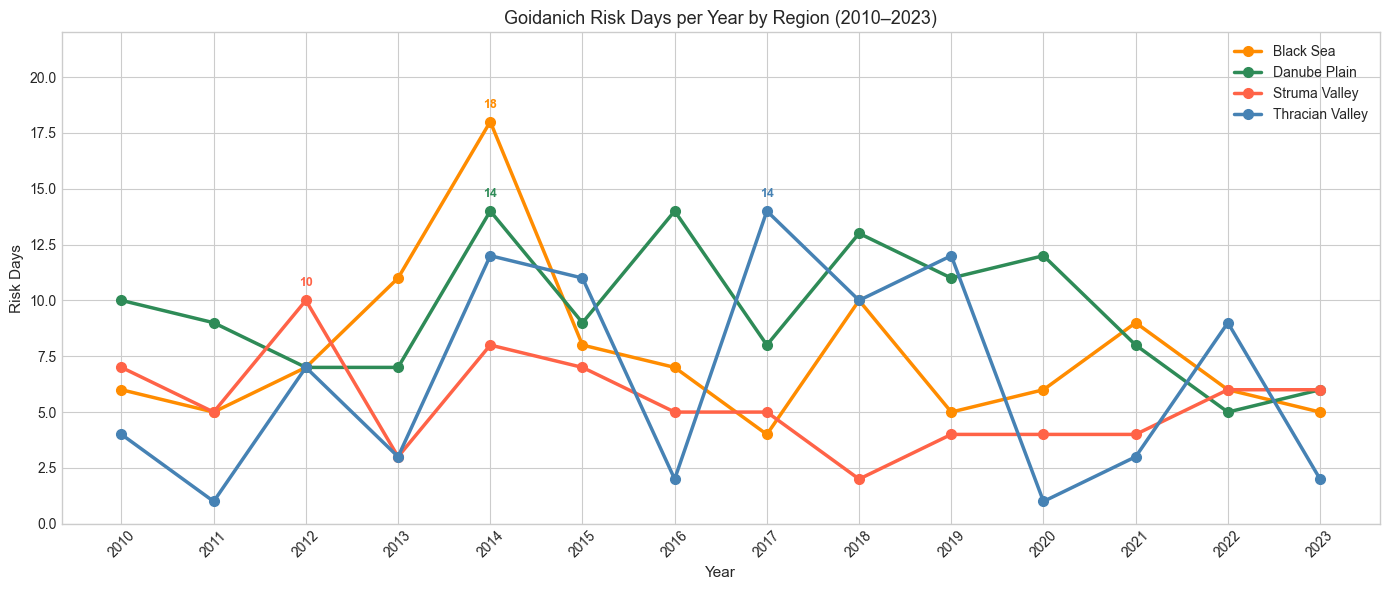

In [47]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = {'Thracian Valley': 'steelblue', 'Struma Valley': 'tomato',
          'Danube Plain': 'seagreen', 'Black Sea': 'darkorange'}

for region, group in risk_by_year.groupby('region'):
    ax.plot(group['year'], group['goidanich_risk'],
            marker='o', linewidth=2.5, markersize=7,
            label=region, color=colors[region])
    
    # Annotation за пиковата година
    peak = group.loc[group['goidanich_risk'].idxmax()]
    ax.annotate(f"{int(peak['goidanich_risk'])}",
                xy=(peak['year'], peak['goidanich_risk']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color=colors[region], fontweight='bold')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Risk Days', fontsize=11)
ax.set_title('Goidanich Risk Days per Year by Region (2010–2023)', fontsize=13)
ax.legend(loc='upper right', framealpha=0.9)
ax.set_xticks(range(2010, 2024))
ax.set_xticklabels(range(2010, 2024), rotation=45)
ax.set_ylim(0, 22)

plt.tight_layout()
plt.show()

Risk day counts vary considerably across years and regions. The year 2014 stands out as the highest-risk year for the `Black Sea` region (18 days) and `Danube Plain` (14 days). The `Struma Valley` consistently records the fewest risk days across all years, while the `Danube Plain` shows the most variable pattern. No clear long-term trend is visible over the 2010-2023 periood - inter-annual variability dominates over any directional change.

### 8.2 Seasonal Risk Distribution by Month

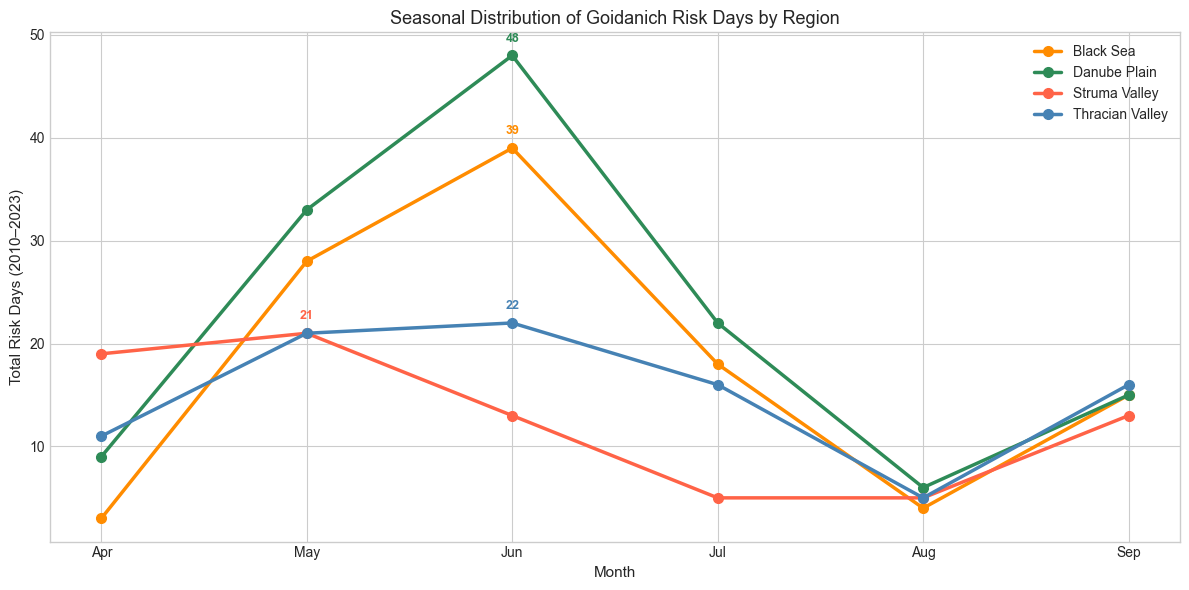

In [51]:
risk_by_month = bg_season.groupby(['region', 'month'])['goidanich_risk'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

month_names = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep']

for region, group in risk_by_month.groupby('region'):
    ax.plot(group['month'], group['goidanich_risk'],
            marker='o', linewidth=2.5, markersize=7,
            label=region, color=colors[region])
    
    peak = group.loc[group['goidanich_risk'].idxmax()]
    ax.annotate(f"{int(peak['goidanich_risk'])}",
                xy=(peak['month'], peak['goidanich_risk']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color=colors[region], fontweight='bold')

ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Risk Days (2010–2023)', fontsize=11)
ax.set_title('Seasonal Distribution of Goidanich Risk Days by Region', fontsize=13)
ax.set_xticks(range(4, 10))
ax.set_xticklabels(month_names)
ax.legend()

plt.tight_layout()
plt.show()

June is the peak risk month for three of the four regions - `Danube Plain (48 days)`, `Black Sea (39 days)` and `Tracian Valley (22 days)`. The `Struma Valley` peaks earlier in April-May `(21 days)` and drops sharply afterwards, consistent with its drier summer climate. August is the lowest-risk month across all regions, coinciding with the typically hot and dry Bulgarian summer.
A secondary risk increase is visible in September for all regions, likely associated with autumn rainfall returnung after the summer dry period.

### 8.3 Comparison: Infection Risk vs. Observed Occurrence

An important distinction exists between the two datasets used in this project:

- **GBIF data** records when *P. viticola* symptoms were *observed* in the field - this typically occurs days to weeks after the actual infection events
- **Goidanich index** identifies days when meteorological conditions are *favourable for infection* - before symptoms became visible

Comparing the seasonal distribution of GBIF observations (Europe, 200-2025) with Bulgarian infection risk, days reveals whether this lag is visible in the data.

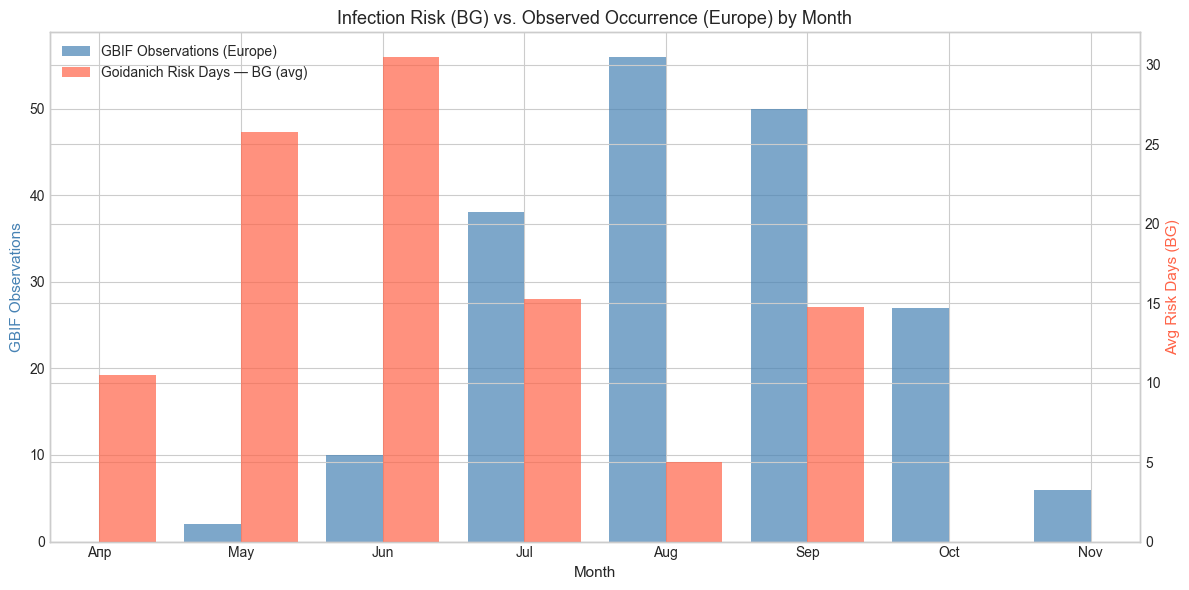

In [58]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# GBIF observations (Europe)
gbif_month_counts = gbif_seasonal['month'].value_counts().sort_index()
ax1.bar(gbif_month_counts.index - 0.2, gbif_month_counts.values,
        width=0.4, color='steelblue', alpha=0.7, label='GBIF Observations (Europe)')

# BG Goidanich risk days (average across regions)
bg_risk_month = bg_season.groupby('month')['goidanich_risk'].sum() / 4
ax2 = ax1.twinx()
ax2.bar(bg_risk_month.index + 0.2, bg_risk_month.values,
        width=0.4, color='tomato', alpha=0.7, label='Goidanich Risk Days — BG (avg)')

ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('GBIF Observations', fontsize=11, color='steelblue')
ax2.set_ylabel('Avg Risk Days (BG)', fontsize=11, color='tomato')
ax1.set_xticks(range(4, 12))
ax1.set_xticklabels(['Апр', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov'])
ax1.set_title('Infection Risk (BG) vs. Observed Occurrence (Europe) by Month', fontsize=13)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

The chart reveals a clear temporal offset between the two datasets. `Goidanich risk` conditions in Bulgaria peak in May–June, while `GBIF observations` across Europe peak in July–August — approximately 1–2 months later. This lag is consistent with the biology of *P. viticola*: infection occurs under favourable meteorological conditions, but symptoms become visible and are recorded by observers only several weeks after the initial infection event.

It should be noted that the two datasets are not directly comparable — `the Goidanich index` reflects conditions in Bulgaria, while `GBIF observations` come predominantly from Western and Central Europe. The absence of Bulgarian records in `GBIF` prevents a more direct regional comparison. Nevertheless, the temporal offset observed here is consistent with the expected infection-to-symptom development timeline.